In [1]:
import pandas as pd
import numpy as np

In [28]:
df=pd.read_excel(r"C:\Users\Asus\Project Folder\output.xlsx")

In [29]:
df['discount'] = df['discount'].astype(str)

df['discount'] = df['discount'].str.replace('% off', '', regex=False)
df['discount'] = pd.to_numeric(df['discount'], errors='coerce')

In [30]:
df['actual_price'] = df['actual_price'].astype(str).str.replace(',', '')
df['actual_price'] = pd.to_numeric(df['actual_price'], errors='coerce')

df['selling_price'] = df['selling_price'].astype(str).str.replace(',', '')
df['selling_price'] = pd.to_numeric(df['selling_price'], errors='coerce')

In [31]:
df['average_rating'] = pd.to_numeric(df['average_rating'], errors='coerce')

In [32]:
df.dropna(subset=['actual_price', 'selling_price', 'average_rating'], inplace=True)

In [7]:
df['discount_percent'] = ((df['actual_price'] - df['selling_price']) / df['actual_price']) * 100

In [8]:
df.groupby('category')['selling_price'].mean().sort_values(ascending=False)

category
Clothing and Accessories    713.537013
Footwear                    496.763860
Bags, Wallets & Belts       258.512195
Toys                        189.000000
Name: selling_price, dtype: float64

In [9]:
df['category'].value_counts()

category
Clothing and Accessories    25923
Footwear                      974
Bags, Wallets & Belts          41
Toys                            1
Name: count, dtype: int64

In [10]:
df.groupby('category')['average_rating'].mean().sort_values(ascending=False)

category
Bags, Wallets & Belts       4.126829
Footwear                    3.875359
Clothing and Accessories    3.630934
Toys                        3.600000
Name: average_rating, dtype: float64

In [11]:
df.groupby('category')['discount_percent'].mean().sort_values(ascending=False)

category
Toys                        62.124248
Bags, Wallets & Belts       61.913871
Clothing and Accessories    50.543886
Footwear                    49.259604
Name: discount_percent, dtype: float64

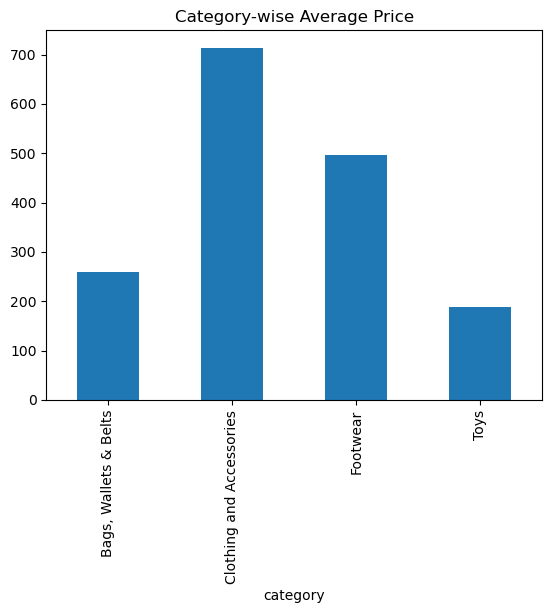

In [12]:
import matplotlib.pyplot as plt

df.groupby('category')['selling_price'].mean().plot(kind='bar')
plt.title("Category-wise Average Price")
plt.xticks(rotation=90)
plt.show()

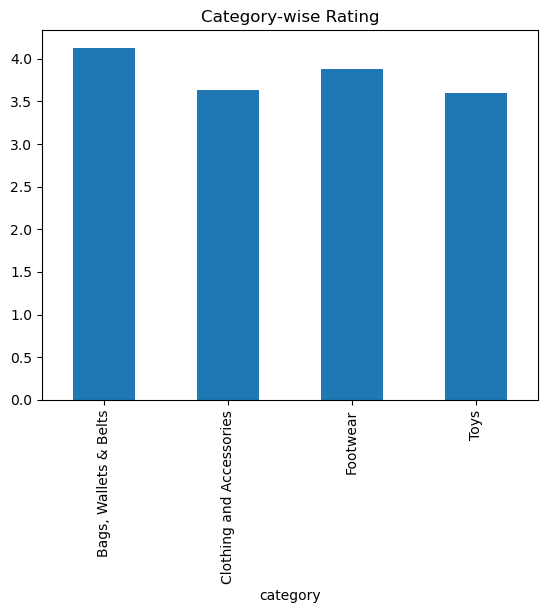

In [13]:
df.groupby('category')['average_rating'].mean().plot(kind='bar')
plt.title("Category-wise Rating")
plt.xticks(rotation=90)
plt.show()

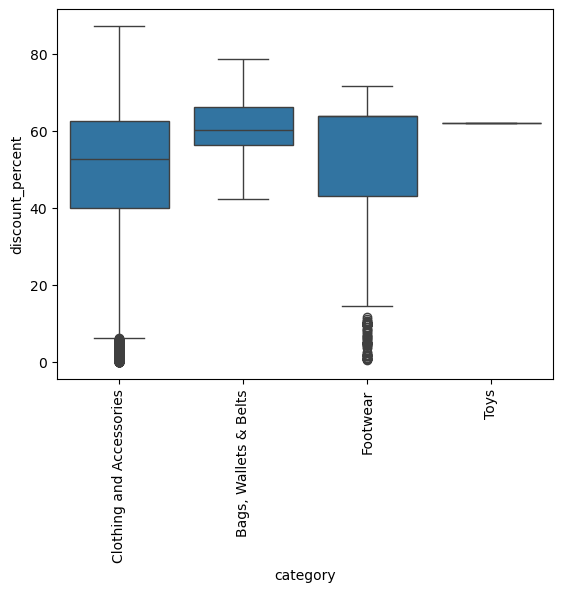

In [14]:
import seaborn as sns

sns.boxplot(x='category', y='discount_percent', data=df)
plt.xticks(rotation=90)
plt.show()

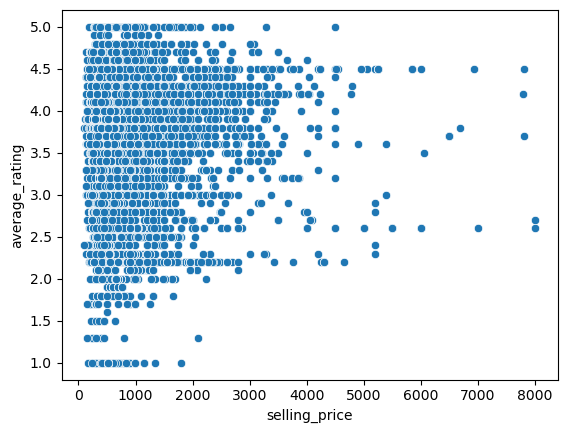

In [15]:
sns.scatterplot(x='selling_price', y='average_rating', data=df)
plt.show()

In [16]:
df.groupby('brand')['selling_price'].mean().sort_values(ascending=False).head(10)

brand
G                 3809.354167
REEBOK CLASSI     1999.611650
Lev               1869.421053
adidas Origina    1665.852459
Wab               1589.023256
U.S.Polo As       1549.225806
Sherr             1495.116667
U.S. POLO ASS     1495.104651
REEB              1474.657648
Pu                1451.123258
Name: selling_price, dtype: float64

In [17]:
df['out_of_stock'].value_counts()

out_of_stock
False    26152
True       787
Name: count, dtype: int64

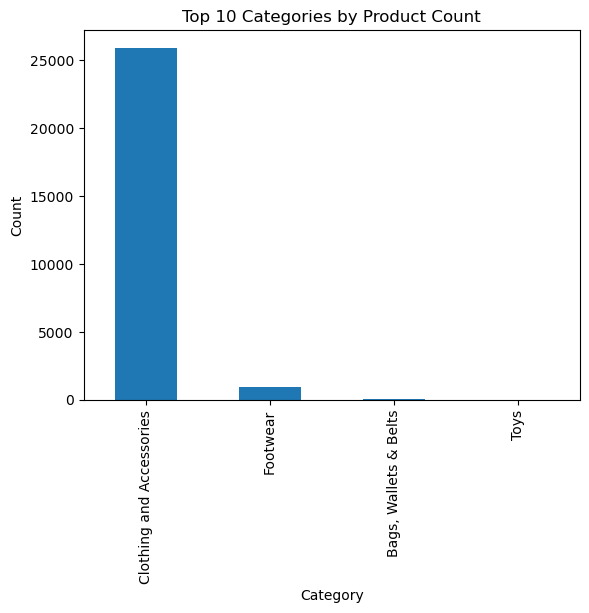

In [18]:
top_cat = df['category'].value_counts().head(10)

top_cat.plot(kind='bar')
plt.title("Top 10 Categories by Product Count")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

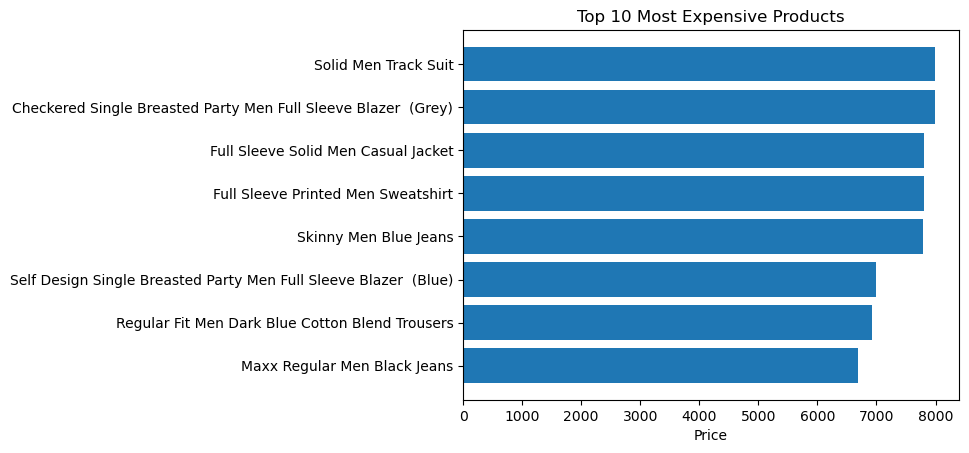

In [19]:
top_exp = df.sort_values(by='selling_price', ascending=False).head(10)

plt.barh(top_exp['title'], top_exp['selling_price'])
plt.title("Top 10 Most Expensive Products")
plt.xlabel("Price")
plt.gca().invert_yaxis()
plt.show()

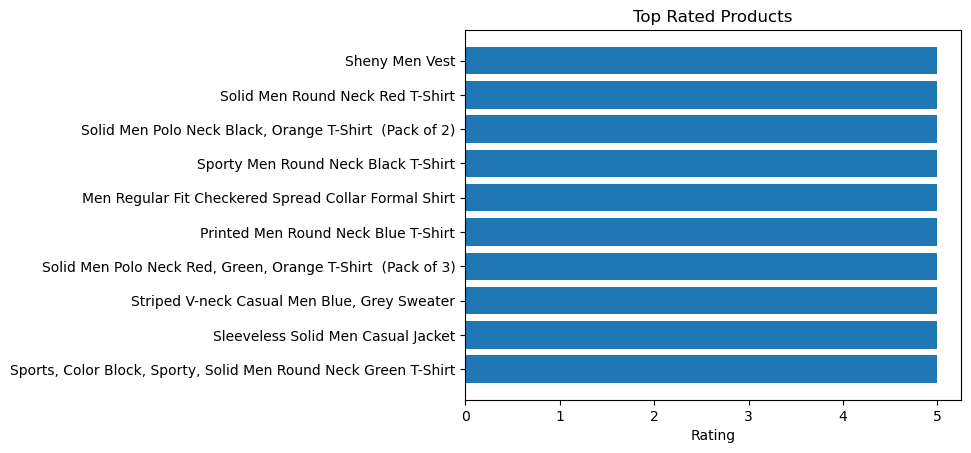

In [20]:
top_rating = df.sort_values(by='average_rating', ascending=False).head(10)

plt.barh(top_rating['title'], top_rating['average_rating'])
plt.title("Top Rated Products")
plt.xlabel("Rating")
plt.gca().invert_yaxis()
plt.show()

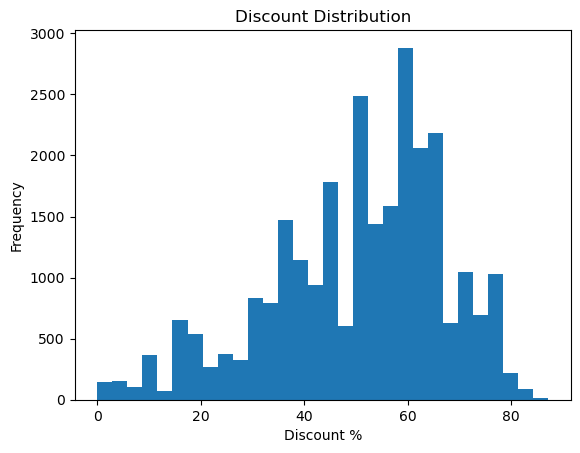

In [21]:
plt.hist(df['discount_percent'], bins=30)
plt.title("Discount Distribution")
plt.xlabel("Discount %")
plt.ylabel("Frequency")
plt.show()

In [22]:
def price_category(price):
    if price < 500:
        return "Low"
    elif price < 2000:
        return "Medium"
    else:
        return "High"

df['price_category'] = df['selling_price'].apply(price_category)

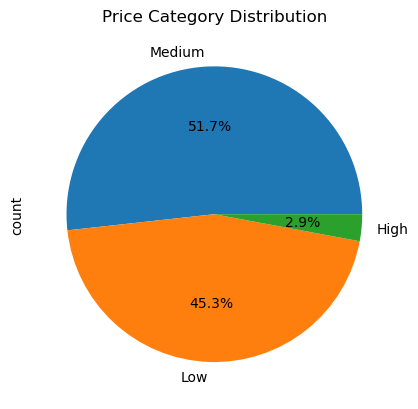

In [23]:
df['price_category'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Price Category Distribution")
plt.show()

In [24]:
print(df.columns)

Index(['Unnamed: 0', '_id', 'actual_price', 'average_rating', 'brand',
       'category', 'crawled_at', 'discount', 'description', 'images',
       'out_of_stock', 'pid', 'product_details', 'seller', 'selling_price',
       'sub_category', 'title', 'url', 'discount_percent', 'price_category'],
      dtype='object')


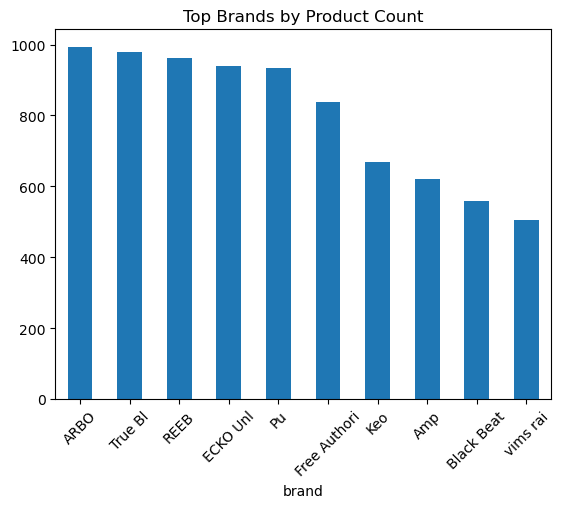

In [25]:
top_brands = df['brand'].value_counts().head(10)

top_brands.plot(kind='bar')
plt.title("Top Brands by Product Count")
plt.xticks(rotation=45)
plt.show()

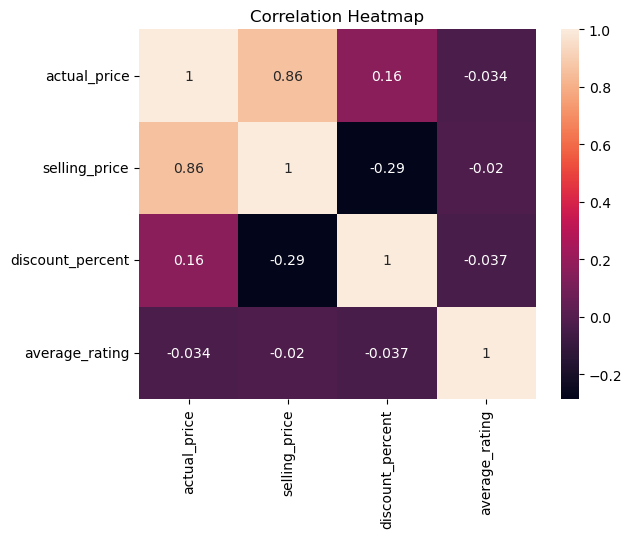

In [26]:
import seaborn as sns

corr = df[['actual_price', 'selling_price', 'discount_percent', 'average_rating']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

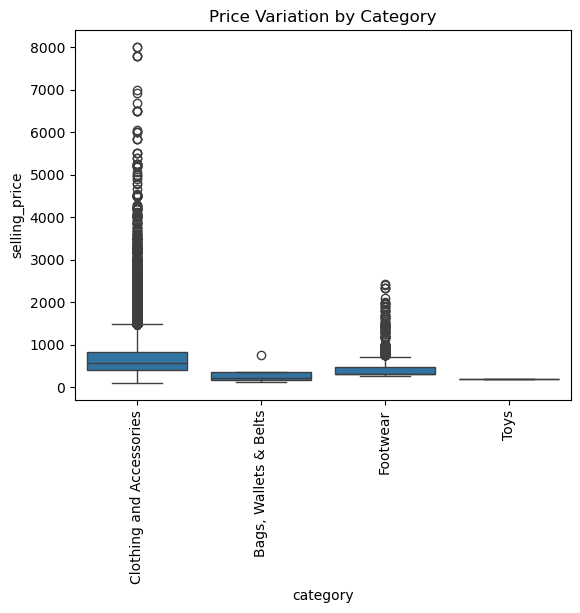

In [27]:
sns.boxplot(x='category', y='selling_price', data=df)
plt.xticks(rotation=90)
plt.title("Price Variation by Category")
plt.show()

In [33]:
df

,Unnamed: 0,_id,actual_price,average_rating,brand,category,crawled_at,discount,description,images,out_of_stock,pid,product_details,seller,selling_price,sub_category,title,url
0,0,fa8e22d6-c0b6-5229-bb9e-ad52eda39a0a,2999.0,3.9,York,Clothing and Accessories,"02/10/2021, 20:11:51",69.0,Yorker trackpants made from 100% rich combed c...,['https://rukminim1.flixcart.com/image/128/128...,False,TKPFCZ9EA7H5FYZH,"[{'Style Code': '1005COMBO2'}, {'Closure': 'El...",Shyam Enterprises,921.0,Bottomwear,Solid Men Multicolor Track Pants,https://www.flipkart.com/yorker-solid-men-mult...
1,1,893e6980-f2a0-531f-b056-34dd63fe912c,1499.0,3.9,York,Clothing and Accessories,"02/10/2021, 20:11:52",66.0,Yorker trackpants made from 100% rich combed c...,['https://rukminim1.flixcart.com/image/128/128...,False,TKPFCZ9EJZV2UVRZ,"[{'Style Code': '1005BLUE'}, {'Closure': 'Draw...",Shyam Enterprises,499.0,Bottomwear,Solid Men Blue Track Pants,https://www.flipkart.com/yorker-solid-men-blue...
2,2,eb4c8eab-8206-59d0-bcd1-a724d96bf74f,2999.0,3.9,York,Clothing and Accessories,"02/10/2021, 20:11:52",68.0,Yorker trackpants made from 100% rich combed c...,['https://rukminim1.flixcart.com/image/128/128...,False,TKPFCZ9EHFCY5Z4Y,"[{'Style Code': '1005COMBO4'}, {'Closure': 'El...",Shyam Enterprises,931.0,Bottomwear,Solid Men Multicolor Track Pants,https://www.flipkart.com/yorker-solid-men-mult...
3,3,3f3f97bb-5faf-57df-a9ff-1af24e2b1045,2999.0,3.9,York,Clothing and Accessories,"02/10/2021, 20:11:53",69.0,Yorker trackpants made from 100% rich combed c...,['https://rukminim1.flixcart.com/image/128/128...,False,TKPFCZ9ESZZ7YWEF,"[{'Style Code': '1005COMBO3'}, {'Closure': 'El...",Shyam Enterprises,911.0,Bottomwear,Solid Men Multicolor Track Pants,https://www.flipkart.com/yorker-solid-men-mult...
4,4,750caa3d-6264-53ca-8ce1-94118a1d8951,2999.0,3.9,York,Clothing and Accessories,"02/10/2021, 20:11:53",68.0,Yorker trackpants made from 100% rich combed c...,['https://rukminim1.flixcart.com/image/128/128...,False,TKPFCZ9EVXKBSUD7,"[{'Style Code': '1005COMBO1'}, {'Closure': 'Dr...",Shyam Enterprises,943.0,Bottomwear,"Solid Men Brown, Grey Track Pants",https://www.flipkart.com/yorker-solid-men-brow...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29992,29992,43604ea8-5e41-501f-a12a-91db266e697a,799.0,3.8,Oka,Clothing and Accessories,"02/11/2021, 01:31:52",49.0,‘OKANE’ endeavors to continue to be a leader i...,['https://rukminim1.flixcart.com/image/128/128...,False,SRTFJ7PNS8Y6XMSY,"[{'Fabric': 'Cotton Blend'}, {'Pattern': 'Soli...",OKANE,400.0,Bottomwear,Solid Men Black Night Shorts,https://www.flipkart.com/okane-solid-men-black...
29993,29993,b040f67e-1671-5744-9f51-a68d21e9e81f,550.0,4.3,Oka,Clothing and Accessories,"02/11/2021, 01:31:53",44.0,NaN,['https://rukminim1.flixcart.com/image/128/128...,True,TSHFWNWF6XZZBEGW,"[{'Type': 'Round Neck'}, {'Sleeve': 'Full Slee...",NaN,303.0,Topwear,Solid Men Round Neck Pink T-Shirt,https://www.flipkart.com/okane-solid-men-round...
29994,29994,e8ec64b6-0f9a-53d7-8b03-b6662ae74af6,949.0,3.8,Oka,Clothing and Accessories,"02/11/2021, 01:31:53",34.0,NaN,['https://rukminim1.flixcart.com/image/128/128...,False,DHYFHFUKFFJSPC98,"[{'Fabric': 'Cotton Blend'}, {'Pattern': 'Chec...",OKANE,617.0,Bottomwear,Checkered Men Multicolor Regular Shorts,https://www.flipkart.com/okane-checkered-men-m...
29996,29996,f2a683e4-634d-5a11-8950-2d56b924576d,799.0,3.8,Oka,Clothing and Accessories,"02/11/2021, 01:31:54",34.0,NaN,['https://rukminim1.flixcart.com/image/128/128...,False,SRTFV8S7DCEWAQVH,"[{'Fabric': 'Polycotton'}, {'Pattern': 'Printe...",OKANE,520.0,Bottomwear,Printed Men Blue Regular Shorts,https://www.flipkart.com/okane-printed-men-blu...
